<a href="https://colab.research.google.com/github/Nadia-dia/Implementation-of-GPT-model/blob/main/GPT_Tiny_Shakespeare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### HYPERPARAMETERS
#### **Chunk** is a piece of the original data.
#### **Block** is how many tokens does the model look at one time, is a sequence window.
#### **Batch** is a group of blocks processed together.


In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 64 # how many independent sequences() will we process in parallel?
block_size = 256 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 500
device= 'cuda' if torch.cuda.is_available() else 'cpu'
learning_rate = 1e-2
eval_iters = 200

torch.manual_seed(1337)


### READING THE DATASET AND BASIC STATISTICS

In [ ]:
# download the tiny shakespeare dataset
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-06-08 23:01:29--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.008s  

2026-06-08 23:01:29 (130 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [ ]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
print("=" * 55)
print(" MAIN STATISTICS ")
print("=" * 55)
print(f"Length of dataset in characters    : {len(text):,}")
print(f"Length of dataset in words (aprox.): {len(text.split()):,}")
print(f"Length of dataset in lines         : {text.count(chr(10)):,}")
print()

 MAIN STATISTICS 
Length of dataset in characters    : 1,115,394
Length of dataset in words (aprox.): 202,651
Length of dataset in lines         : 40,000



In [ ]:
chars=sorted(list(set(text)))
vocab_size = len(chars)
print('Whole vobabulary:',repr(''.join(chars)))
print('Vocabulary size:', vocab_size)

Whole vobabulary: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
Vocabulary size: 65


In [ ]:
print("\n" + "=" * 55)
print("FIRST 500 CHARS OF SET")
print("=" * 55)
print(text[:500])



FIRST 500 CHARS OF SET
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


### FREQUENCY OF CHARS ANALYSIS

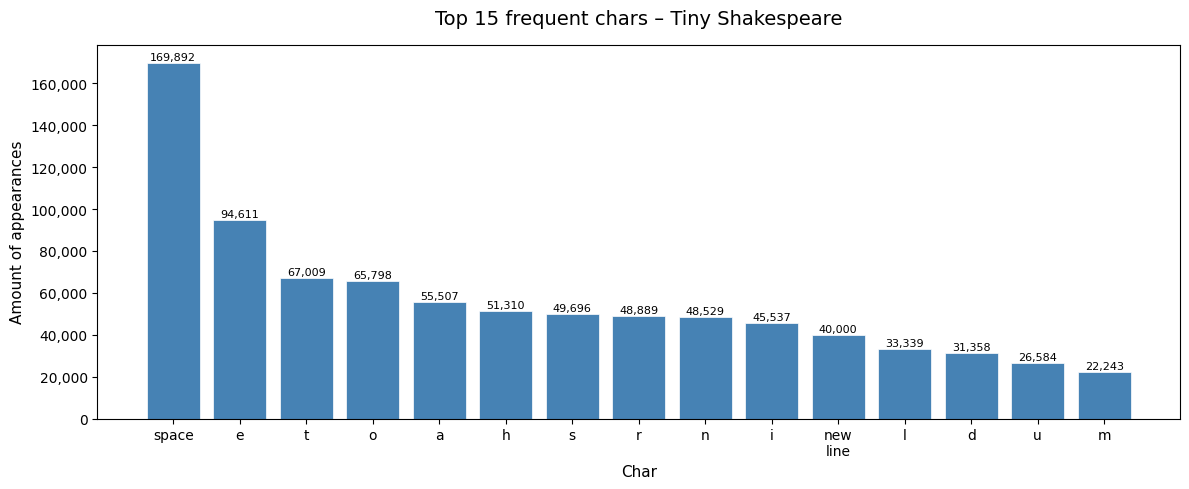

Figure saved as: wykres_czestosci_znakow.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

counts = Counter(text)

# --- Wykres 1: Top 15 najczęstszych znaków ---
top_n = 15
labels_raw, values = zip(*counts.most_common(top_n))

# Zmiana: niewidoczne znaki na czytelne etykiety
def readable_label(ch):
    if ch == ' ':  return 'space'
    if ch == '\n': return 'new\nline'
    return ch

labels = [readable_label(c) for c in labels_raw]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, values, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title(f"Top {top_n} frequent chars – Tiny Shakespeare", fontsize=14, pad=15)
ax.set_xlabel("Char", fontsize=11)
ax.set_ylabel("Amount of appearances", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig("wykres_czestosci_znakow.png", dpi=150)
plt.show()
print("Figure saved as: wykres_czestosci_znakow.png")

### TOKENIZATION

In [ ]:
# create a mapping from characters to integers
stoi = { ch: i for i, ch in enumerate(chars)}
itoi = { i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join(itoi[i] for i in l) # decoder: take a list of integers, output a string

example = "Hello, Shakespeare!"
encoded = encode(example)
decoded = decode(encoded)

print(f"Original text : {repr(example)}")
print(f"After encode(): {encoded}")
print(f"After decode(): {repr(decoded)}")
print(f"Roundtrip OK? : {example == decoded}")

Original text : 'Hello, Shakespeare!'
After encode(): [20, 43, 50, 50, 53, 6, 1, 31, 46, 39, 49, 43, 57, 54, 43, 39, 56, 43, 2]
After decode(): 'Hello, Shakespeare!'
Roundtrip OK? : True


### TRAIN AND TEST SPLITS

In [ ]:
data=torch.tensor(encode(text),dtype=torch.long)
n = int(0.9*len(text)) # first 90% will be train, rest val
train_data=data[:n]
val_data=data[n:]

print(f"Tensor of data: shape={data.shape}, type={data.dtype}")
print(f"Training data: {len(train_data):,} tokens  ({100*len(train_data)/len(data):.0f}%)")
print(f"Validation data: {len(val_data):,} tokens  ({100*len(val_data)/len(data):.0f}%)")


Tensor of data: shape=torch.Size([1115394]), type=torch.int64
Training data: 1,003,854 tokens  (90%)
Validation data: 111,540 tokens  (10%)


### SEQUENCE DEMONSTRATION

In [ ]:
x = train_data[:block_size] # inputs for the transformer
y = train_data[1:block_size+1] # targets for the transfomer
print(type(x), x)

print(f"block_size = {block_size}")
print(f"Inputs  x : {x.tolist()}")
print(f"Targets y : {y.tolist()}")
print()
print("Pair examples (context → next token):")

for i in range(block_size):
  context=x[:i+1]
  target=y[i]
  print(f'when input is {context} the target: {target}')

<class 'torch.Tensor'> tensor([18, 47, 56, 57, 58,  1, 15, 47])
block_size = 8
Inputs  x : [18, 47, 56, 57, 58, 1, 15, 47]
Targets y : [47, 56, 57, 58, 1, 15, 47, 58]

Pair examples (context → next token):
when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


### SPLITING DATA FOR BATCHES

In [ ]:
# data loading (batch)
def get_batch(split):
  # generate a small batch of data of inputs x and targets y
  data = train_data if split=='train' else val_data
  ix = torch.randint(len(data)-block_size, (batch_size,)) # batch_size amount random starting positions
  x = torch.stack([data[i:i+block_size] for i in ix]) # input
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])# target
  x, y = x.to(device), y.to(device)
  return x, y

xb, yb = get_batch('train')
print('inputs')
print(xb.shape)
print(xb)
print('targets')
print(yb.shape)
print(yb)

for b in range(batch_size): # which batch
  for t in range(block_size): # position inside the current batch.
    context = xb[b, :t+1]
    target = yb[b, t]
    print(f'When input is {context.tolist()} the target: {target}')



inputs
torch.Size([4, 8])
tensor([[57, 43, 60, 43, 52,  1, 63, 43],
        [60, 43, 42,  8,  0, 25, 63,  1],
        [56, 42,  5, 57,  1, 57, 39, 49],
        [43, 57, 58, 63,  6,  1, 58, 46]])
targets
torch.Size([4, 8])
tensor([[43, 60, 43, 52,  1, 63, 43, 39],
        [43, 42,  8,  0, 25, 63,  1, 45],
        [42,  5, 57,  1, 57, 39, 49, 43],
        [57, 58, 63,  6,  1, 58, 46, 47]])
When input is [57] the target: 43
When input is [57, 43] the target: 60
When input is [57, 43, 60] the target: 43
When input is [57, 43, 60, 43] the target: 52
When input is [57, 43, 60, 43, 52] the target: 1
When input is [57, 43, 60, 43, 52, 1] the target: 63
When input is [57, 43, 60, 43, 52, 1, 63] the target: 43
When input is [57, 43, 60, 43, 52, 1, 63, 43] the target: 39
When input is [60] the target: 43
When input is [60, 43] the target: 42
When input is [60, 43, 42] the target: 8
When input is [60, 43, 42, 8] the target: 0
When input is [60, 43, 42, 8, 0] the target: 25
When input is [60, 43, 4

In [ ]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

### Training the model

In [ ]:
# idea: Given the current token, predict the next token.
class BigramLanguageModel(nn.Module):

  def __init__(self, vocab_size):
     super().__init__()
     # each token directly reads off the logits for the next token from a lookup table
     # initially random numbers
     self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

  def forward(self, idx, targets=None):
      # idx and targets are both (B,T) tensor of integers
      logits=self.token_embedding_table(idx) # (B,T,C) - batch_size, time/block size, voc_size

      if targets is None:
        loss = None
      else:
        B, T, C = logits.shape
        logits = logits.view(B*T, C)
        targets = targets.view(B*T)
        loss = F.cross_entropy(logits, targets)

      return logits, loss

  def generate(self, idx, max_new_tokens):
      # idx is (B, T) array of indices in the current context
      for _ in range(max_new_tokens):
          # get the predictions
          logits, loss = self(idx)
          # focus only on the last time step/position in block
          logits = logits[:, -1, :] # becomes (B, C)
          # apply softmax to get probabilities from scores (normalization)
          probs = F.softmax(logits, dim=-1) # (B, C)
          # choose sample from the distribution
          idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
          # append sampled index to the running sequence
          idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
      return idx

model = BigramLanguageModel(vocab_size)
m=model.to(device)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(decode(m.generate(idx = torch.zeros((1,1), dtype=torch.long), max_new_tokens=100)[0].tolist()))


torch.Size([256, 65])
tensor(4.6927, grad_fn=<NllLossBackward0>)

SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ


In [ ]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):
  # every once in a while evaluate the loss on train and val sets
  if iter % eval_interval == 0:
    losses = estimate_loss()
    print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

  # sample a batch of data
  xb, yb = get_batch('train')

  # evaluate the loss
  logits, loss = m(xb, yb)
  optimizer.zero_grad(set_to_none=True)
  loss.backward()
  optimizer.step()

print(loss.item())


step 0: train loss 4.7296, val loss 4.7235
step 300: train loss 2.7999, val loss 2.8196
step 600: train loss 2.5423, val loss 2.5672
step 900: train loss 2.4951, val loss 2.5167
step 1200: train loss 2.4728, val loss 2.4994
step 1500: train loss 2.4655, val loss 2.4972
step 1800: train loss 2.4687, val loss 2.4975
step 2100: train loss 2.4663, val loss 2.4859
step 2400: train loss 2.4573, val loss 2.4897
step 2700: train loss 2.4670, val loss 2.4978
2.433833360671997


In [ ]:
# generate from the model
context = torch.zeros((1,1), dtype=torch.long)
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))



SqHa!zoliXSP : nGUhd?lg&qf m;DTHM:l,vcm g pxRixlMgO&YwhcoBLCUd&vZINLIzkuTGra
D. sirsCJGJdacLZa!qB-pr


### The mathematical trick in self-attention

In [ ]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / torch.sum(a, 1, keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
print('b=')
print(b)
print('--')
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


In [ ]:
# consider the following toy example:

torch.manual_seed(1337)
B,T,C = 4,8,2 # batch, time, channels
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

In [ ]:
# version 1
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)

xbow

tensor([[[ 0.1808, -0.0700],
         [-0.0894, -0.4926],
         [ 0.1490, -0.3199],
         [ 0.3504, -0.2238],
         [ 0.3525,  0.0545],
         [ 0.0688, -0.0396],
         [ 0.0927, -0.0682],
         [-0.0341,  0.1332]],

        [[ 1.3488, -0.1396],
         [ 0.8173,  0.4127],
         [-0.1342,  0.4395],
         [ 0.2711,  0.4774],
         [ 0.2421,  0.0694],
         [ 0.0084,  0.0020],
         [ 0.0712, -0.1128],
         [ 0.2527,  0.2149]],

        [[-0.6631, -0.2513],
         [ 0.1735, -0.0649],
         [ 0.1685,  0.3348],
         [-0.1621,  0.1765],
         [-0.2312, -0.0436],
         [-0.1015, -0.2855],
         [-0.2593, -0.1630],
         [-0.3015, -0.2293]],

        [[ 1.6455, -0.8030],
         [ 1.4985, -0.5395],
         [ 0.4954,  0.3420],
         [ 1.0623, -0.1802],
         [ 1.1401, -0.4462],
         [ 1.0870, -0.4071],
         [ 1.0430, -0.1299],
         [ 1.1138, -0.1641]]])

In [ ]:
# version 2: using matrix multiply for a weighted aggregation
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
torch.allclose(xbow, xbow2, atol=1e-6)

True

In [ ]:
# version 3: use Softmax
tril = torch.tril(torch.ones(T, T))
wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
xbow3 = wei @ x
torch.allclose(xbow, xbow3, atol=1e-6)

True

In [ ]:
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

In [ ]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

In [ ]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

In [ ]:
x[:,0].mean(), x[:,0].std() # mean,std of one feature across all batch inputs

(tensor(0.1469), tensor(0.8803))

In [ ]:
x[0,:].mean(), x[0,:].std() # mean,std of a single input from the batch, of its features

(tensor(-9.5367e-09), tensor(1.0000))

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 64 # (16) how many independent sequences will we process in parallel?
block_size = 256 # (32) what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 3e-4 # (1e-3)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384 # (64)
n_head = 6 # (4)
n_layer = 6 # (4)
dropout = 0.2 # (0.0)
# ------------

torch.manual_seed(1337)

# wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,C)
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T)
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:]
            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


10.788929 M parameters
step 0: train loss 4.2849, val loss 4.2823
step 100: train loss 2.4737, val loss 2.4894
step 200: train loss 2.4166, val loss 2.4449
step 300: train loss 2.3244, val loss 2.3536
step 400: train loss 2.1421, val loss 2.1928
step 500: train loss 1.9984, val loss 2.0860
step 600: train loss 1.8848, val loss 2.0048
step 700: train loss 1.7877, val loss 1.9319
step 800: train loss 1.7113, val loss 1.8637
step 900: train loss 1.6491, val loss 1.8179
step 1000: train loss 1.6001, val loss 1.7815
step 1100: train loss 1.5586, val loss 1.7410
step 1200: train loss 1.5206, val loss 1.7139
step 1300: train loss 1.4893, val loss 1.6855
step 1400: train loss 1.4614, val loss 1.6605
step 1500: train loss 1.4350, val loss 1.6420
step 1600: train loss 1.4190, val loss 1.6291
step 1700: train loss 1.3947, val loss 1.6060
step 1800: train loss 1.3759, val loss 1.5986
step 1900: train loss 1.3589, val loss 1.5873
step 2000: train loss 1.3452, val loss 1.5735
step 2100: train loss 1